# YAFS Link Trace Analysis

This notebook analyzes the `sim_trace_link.csv` file, which contains detailed logs of message transmissions over network links in the YAFS simulation.

**Key Metrics Analyzed:**
- **Latency:** The time taken for a message to travel from source to destination.
- **Traffic Volume:** The number of messages and total data size transferred between nodes.
- **Buffer Usage:** The utilization of link buffers during the simulation.
- **Network Topology:** Communication patterns between different nodes (Fog, Cloud, Sensors).

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
We will load the `sim_trace_link.csv` file and examine its structure, data types, and basic statistics.

In [ ]:
# Load the dataset
# Update to the specific results file generated by the tutorial
# file_path = 'resultados/fog2-middle8-end31-latency-sim_trace.csv'

# Load the dataset
# Update to the specific results file generated by the tutorial
file_to_load = "cloud1-gateway12-fog12-end48"
strategy = "roundrobin"
file_path = f"resultados/{file_to_load}-{strategy}-sim_trace_link.csv"
df_link = pd.read_csv(file_path)


df_link['total_delay'] = df_link['latency'] + df_link['wait']

# Display the first few rows
display(df_link.head())

# Check data types and missing values
print(df_link.info())

# Basic descriptive statistics
display(df_link.describe())

,id,type,src,dst,srcLabel,dstLabel,app,latency,wait,message,ctime,size,buffer,total_delay
0,1,LINK,26,2,EndDevice-1,Gateway-1,Application-1,2.0,0.0,M_Req,100.0,1365,0,2.0
1,2,LINK,27,2,EndDevice-2,Gateway-1,Application-2,2.0,0.0,M_Req,100.0,1486,1,2.0
2,3,LINK,28,2,EndDevice-3,Gateway-1,Application-3,2.0,0.0,M_Req,100.0,1659,2,2.0
3,4,LINK,29,2,EndDevice-4,Gateway-1,Application-4,2.0,0.0,M_Req,100.0,1658,3,2.0
4,5,LINK,30,4,EndDevice-5,Gateway-2,Application-5,2.0,0.0,M_Req,100.0,1964,4,2.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134800 entries, 0 to 134799
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           134800 non-null  int64  
 1   type         134800 non-null  object 
 2   src          134800 non-null  int64  
 3   dst          134800 non-null  int64  
 4   srcLabel     134800 non-null  object 
 5   dstLabel     134800 non-null  object 
 6   app          134800 non-null  object 
 7   latency      134800 non-null  float64
 8   wait         134800 non-null  float64
 9   message      134800 non-null  object 
 10  ctime        134800 non-null  float64
 11  size         134800 non-null  int64  
 12  buffer       134800 non-null  int64  
 13  total_delay  134800 non-null  float64
dtypes: float64(4), int64(5), object(5)
memory usage: 14.4+ MB
None


,id,src,dst,latency,wait,ctime,size,buffer,total_delay
count,134800.000000,134800.000000,134800.000000,1.348000e+05,134800.000000,134800.000000,134800.000000,134800.000000,134800.000000
mean,21440.111454,24.215920,18.978316,2.000000e+00,0.872438,50293.504370,1499.697582,28.695749,2.872438
std,12432.048504,19.907473,15.526947,9.567608e-09,1.766710,28621.076231,290.161657,13.805627,1.766710
min,1.000000,2.000000,2.000000,2.000000e+00,0.000000,100.000000,1000.000000,0.000000,2.000000
25%,10750.750000,8.000000,8.000000,2.000000e+00,0.000000,25709.535000,1247.000000,17.000000,2.000000
50%,21382.500000,18.000000,16.000000,2.000000e+00,0.000000,50200.000000,1500.000000,30.000000,2.000000
75%,32170.250000,36.000000,23.000000,2.000000e+00,0.016667,75002.000000,1749.000000,38.000000,2.016667
max,43035.000000,73.000000,73.000000,2.000000e+00,6.000000,99912.069481,2000.000000,47.000000,8.000000


In [50]:
# Load the Application Trace (End-to-End Latency)
# This file contains the full request-response times, including queuing and processing.
app_trace_path = f"resultados/{file_to_load}-{strategy}-sim_trace.csv"

df_app = pd.read_csv(app_trace_path)

# Calculate End-to-End Latency
df_app['latency'] = df_app['service']

# Display basic stats
print("Application End-to-End Latency Stats:")
display(df_app['latency'].describe())

display(df_app.head())

Application End-to-End Latency Stats:


count    48730.000000
mean         0.020610
std          0.023730
min          0.000002
25%          0.000004
50%          0.007412
75%          0.036741
max          0.074074
Name: latency, dtype: float64

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception,latency
0,10,COMP_M,Application-10,Application-10-Service,M_Req,29,30,35,7,EndDevice-10,Fog-3,Application-10-EndDevice,0.034815,104.0,104.034815,100.0,104.0,0.034815
1,31,COMP_M,Application-31,Application-31-Service,M_Req,92,93,56,17,EndDevice-31,Fog-8,Application-31-EndDevice,0.019185,104.0,104.019185,100.0,104.0,0.019185
2,47,COMP_M,Application-47,Application-47-Service,M_Req,140,141,72,25,EndDevice-47,Fog-12,Application-47-EndDevice,0.031778,104.0,104.031778,100.0,104.0,0.031778
3,21,COMP_M,Application-21,Application-21-Service,M_Req,62,63,46,13,EndDevice-21,Fog-6,Application-21-EndDevice,0.071111,104.0,104.071111,100.0,104.0,0.071111
4,16,COMP_M,Application-16,Application-16-Service,M_Req,47,48,41,9,EndDevice-16,Fog-4,Application-16-EndDevice,0.062667,104.0,104.062667,100.0,104.0,0.062667


## 1.1 Application End-to-End Latency Analysis
**Important:** The `sim_trace_link.csv` analyzed above shows *physical link latency* (Transmission + Propagation), which is often constant in stable networks.
The `sim_trace.csv` loaded here shows **End-to-End Latency**, which includes:
1.  **Queuing Delay:** Time waiting in buffers (congestion).
2.  **Processing Time:** Time spent in the Service module.
3.  **Network Latency:** Sum of all link latencies.

**This metric should show significant variation if the network or nodes are busy.**

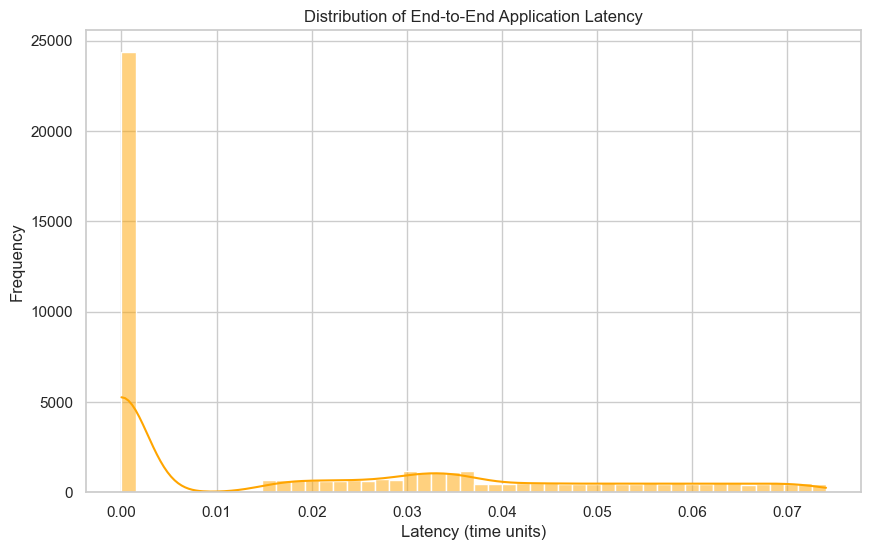

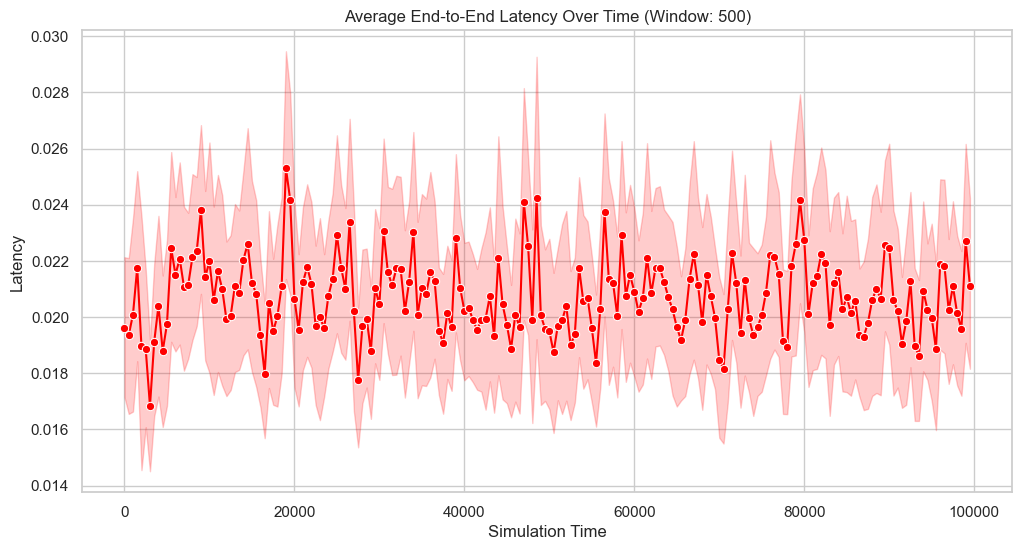

/var/folders/4p/n9x4kgk91xz0trg77jqf12rm0000gn/T/ipykernel_8205/714266847.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='app', y='latency', data=df_app_top20, palette='Set3')


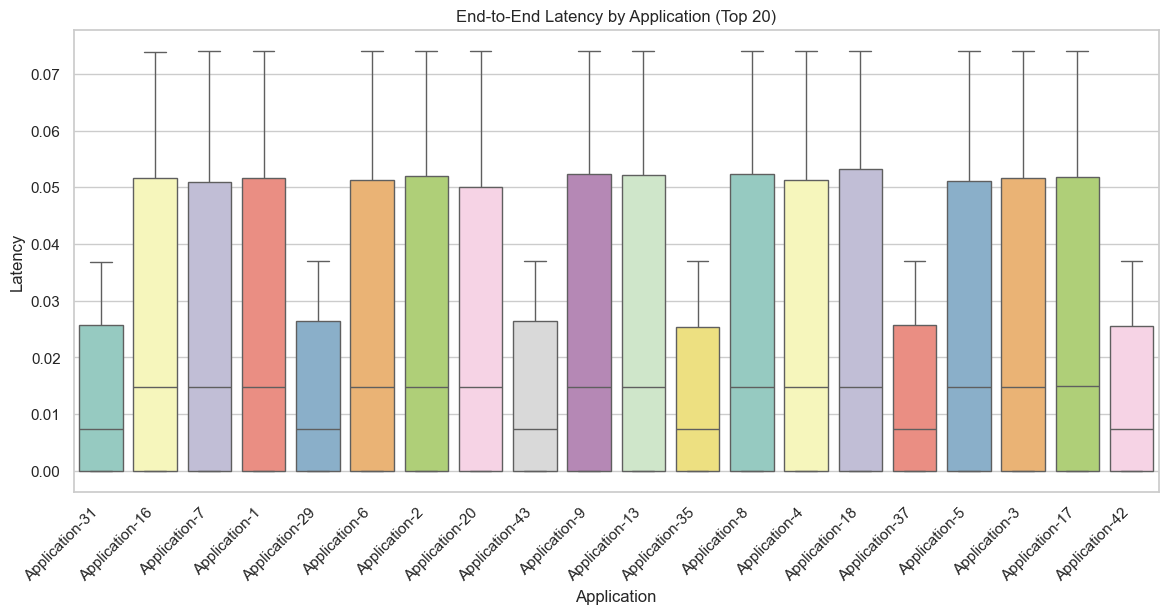

In [51]:
# 1. Distribution of End-to-End Latency
plt.figure(figsize=(10, 6))
sns.histplot(df_app['latency'], kde=True, bins=50, color='orange')
plt.title('Distribution of End-to-End Application Latency')
plt.xlabel('Latency (time units)')
plt.ylabel('Frequency')
plt.show()

# 2. End-to-End Latency Over Time
# Binning time to see trends
window_size_app = 500
df_app['time_window'] = (df_app['time_emit'] // window_size_app) * window_size_app

plt.figure(figsize=(12, 6))
sns.lineplot(x='time_window', y='latency', data=df_app, marker='o', color='red')
plt.title(f'Average End-to-End Latency Over Time (Window: {window_size_app})')
plt.xlabel('Simulation Time')
plt.ylabel('Latency')
plt.grid(True)
plt.show()

# 3. Latency by Application (Top 20)
top_20_apps_e2e = df_app['app'].value_counts().nlargest(20).index
df_app_top20 = df_app[df_app['app'].isin(top_20_apps_e2e)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='app', y='latency', data=df_app_top20, palette='Set3')
plt.title('End-to-End Latency by Application (Top 20)')
plt.xlabel('Application')
plt.ylabel('Latency')
plt.xticks(rotation=45, ha='right')
plt.show()

## 2. Latency Analysis
Latency is a critical metric in network simulations. We will analyze the distribution of latency and compare it across different applications.

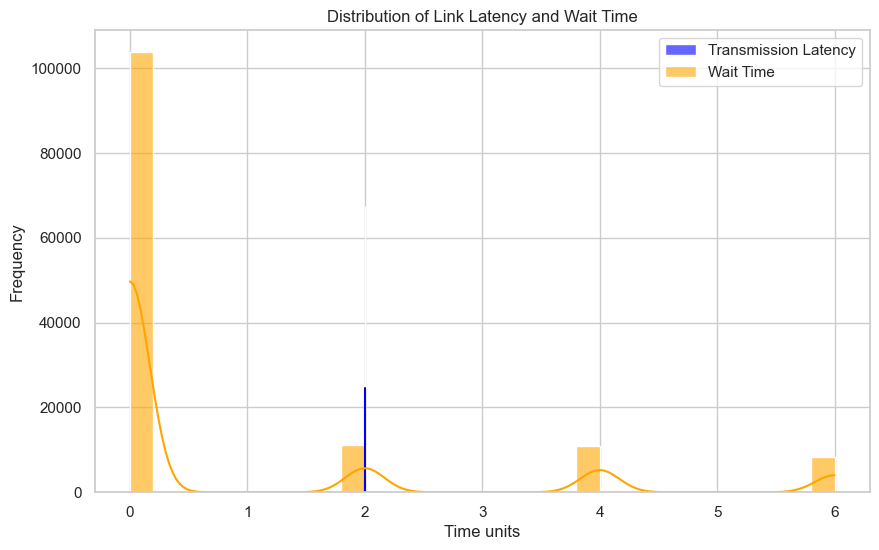

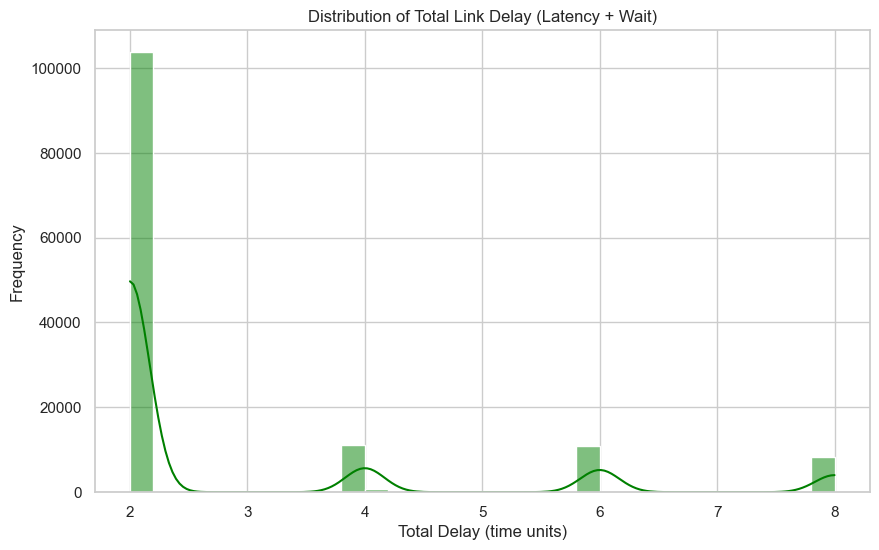

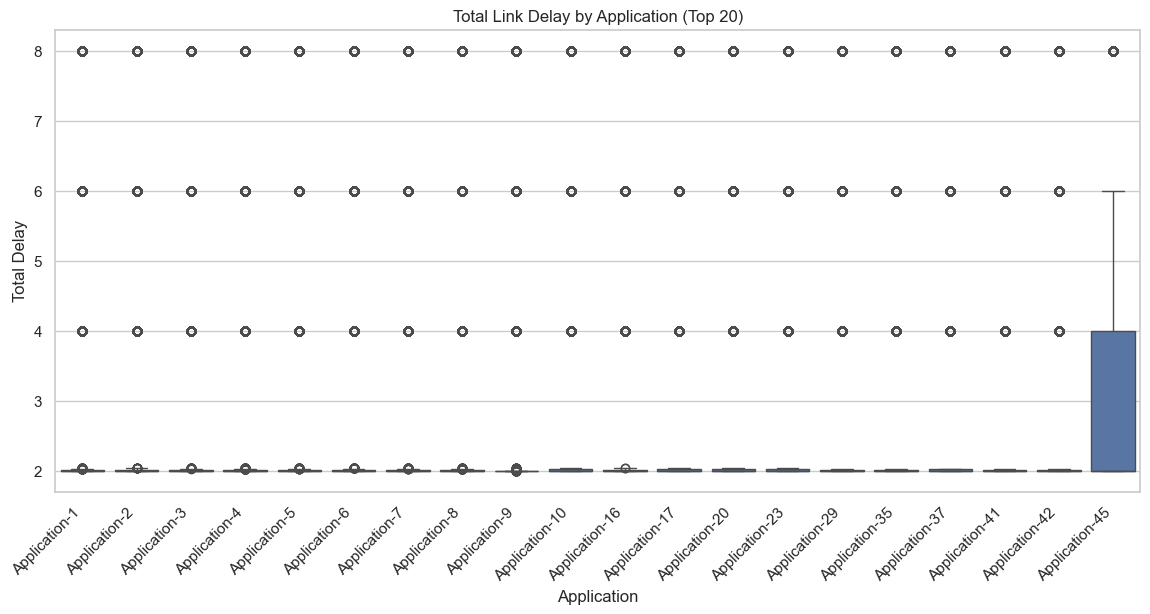

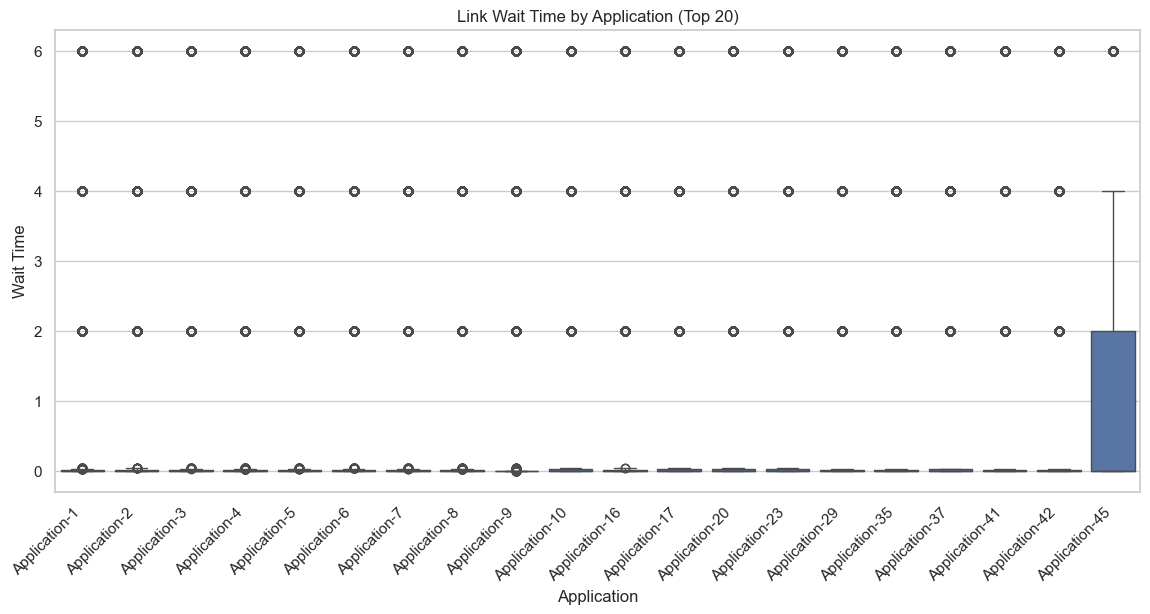

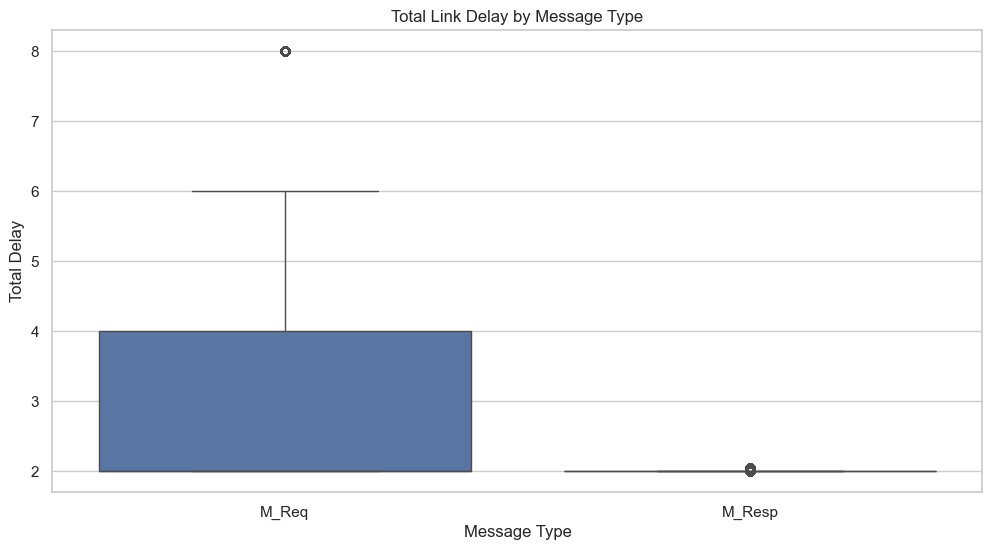

In [52]:
# Latency Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_link['latency'], kde=True, bins=30, label='Transmission Latency', color='blue', alpha=0.6)
if 'wait' in df_link.columns:
    sns.histplot(df_link['wait'], kde=True, bins=30, label='Wait Time', color='orange', alpha=0.6)
plt.title('Distribution of Link Latency and Wait Time')
plt.xlabel('Time units')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Total Delay Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_link['total_delay'], kde=True, bins=30, color='green')
plt.title('Distribution of Total Link Delay (Latency + Wait)')
plt.xlabel('Total Delay (time units)')
plt.ylabel('Frequency')
plt.show()

# Latency by Application Boxplot (Top 20)
# Filtering to the top 20 applications to ensure the plot is readable.
top_20_apps = df_link['app'].value_counts().nlargest(20).index
df_top_20 = df_link[df_link['app'].isin(top_20_apps)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='app', y='total_delay', data=df_top_20)
plt.title('Total Link Delay by Application (Top 20)')
plt.xlabel('Application')
plt.ylabel('Total Delay')
plt.xticks(rotation=45, ha='right') # Rotate and align for better readability
plt.show()

# Wait Time by Application Boxplot (Top 20)
if 'wait' in df_link.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='app', y='wait', data=df_top_20)
    plt.title('Link Wait Time by Application (Top 20)')
    plt.xlabel('Application')
    plt.ylabel('Wait Time')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Latency by Message Type
# Since we have different message types (M_Req, M_Resp), it's useful to see their latency
if 'message' in df_link.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='message', y='total_delay', data=df_link)
    plt.title('Total Link Delay by Message Type')
    plt.xlabel('Message Type')
    plt.ylabel('Total Delay')
    plt.show()

### Latency Trends Over Time
Analyzing how latency changes over time can reveal network congestion or the impact of dynamic placement strategies. We bin the simulation time into windows and calculate the average latency for each window.

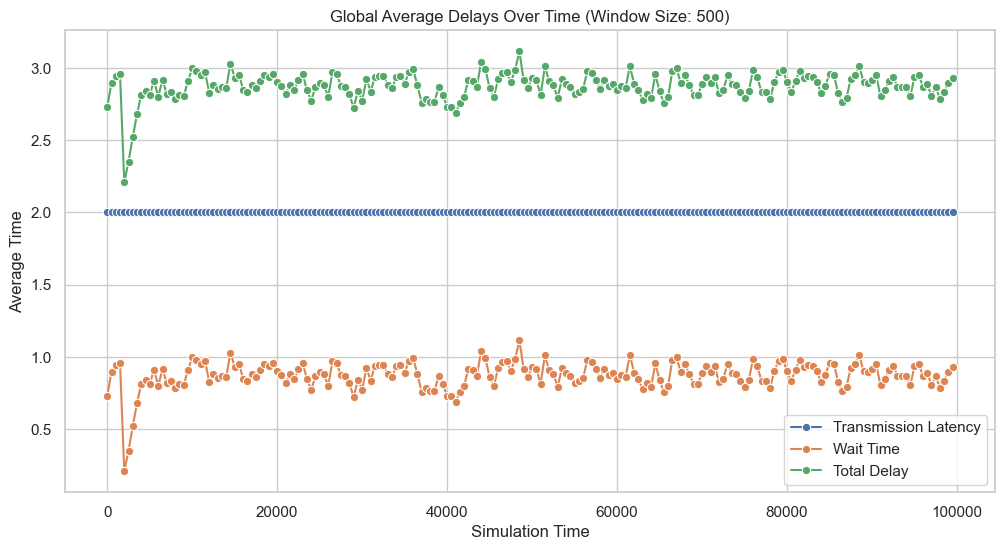

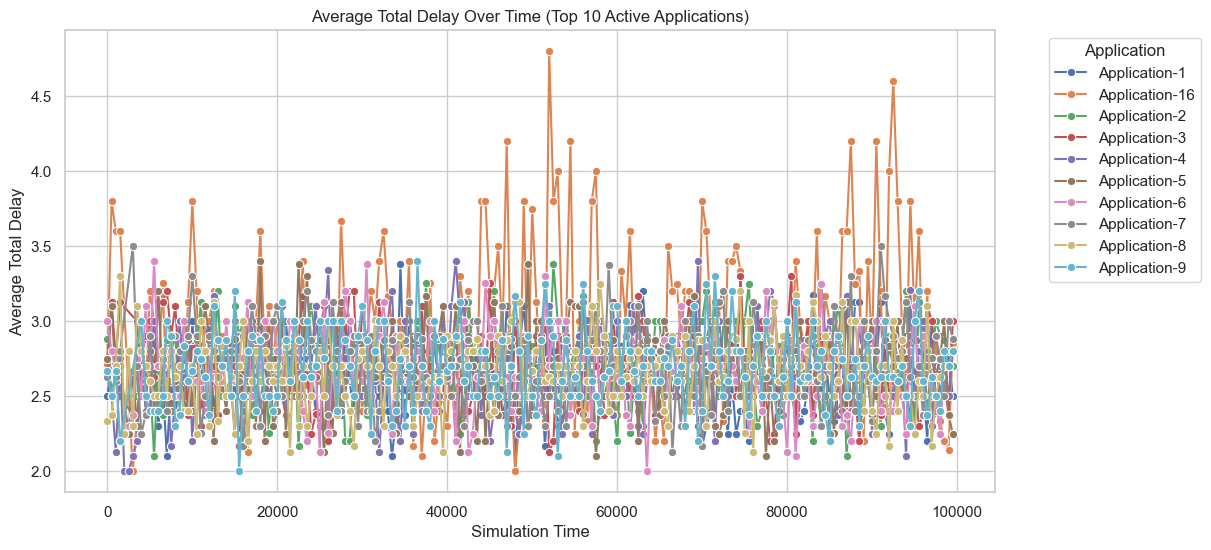

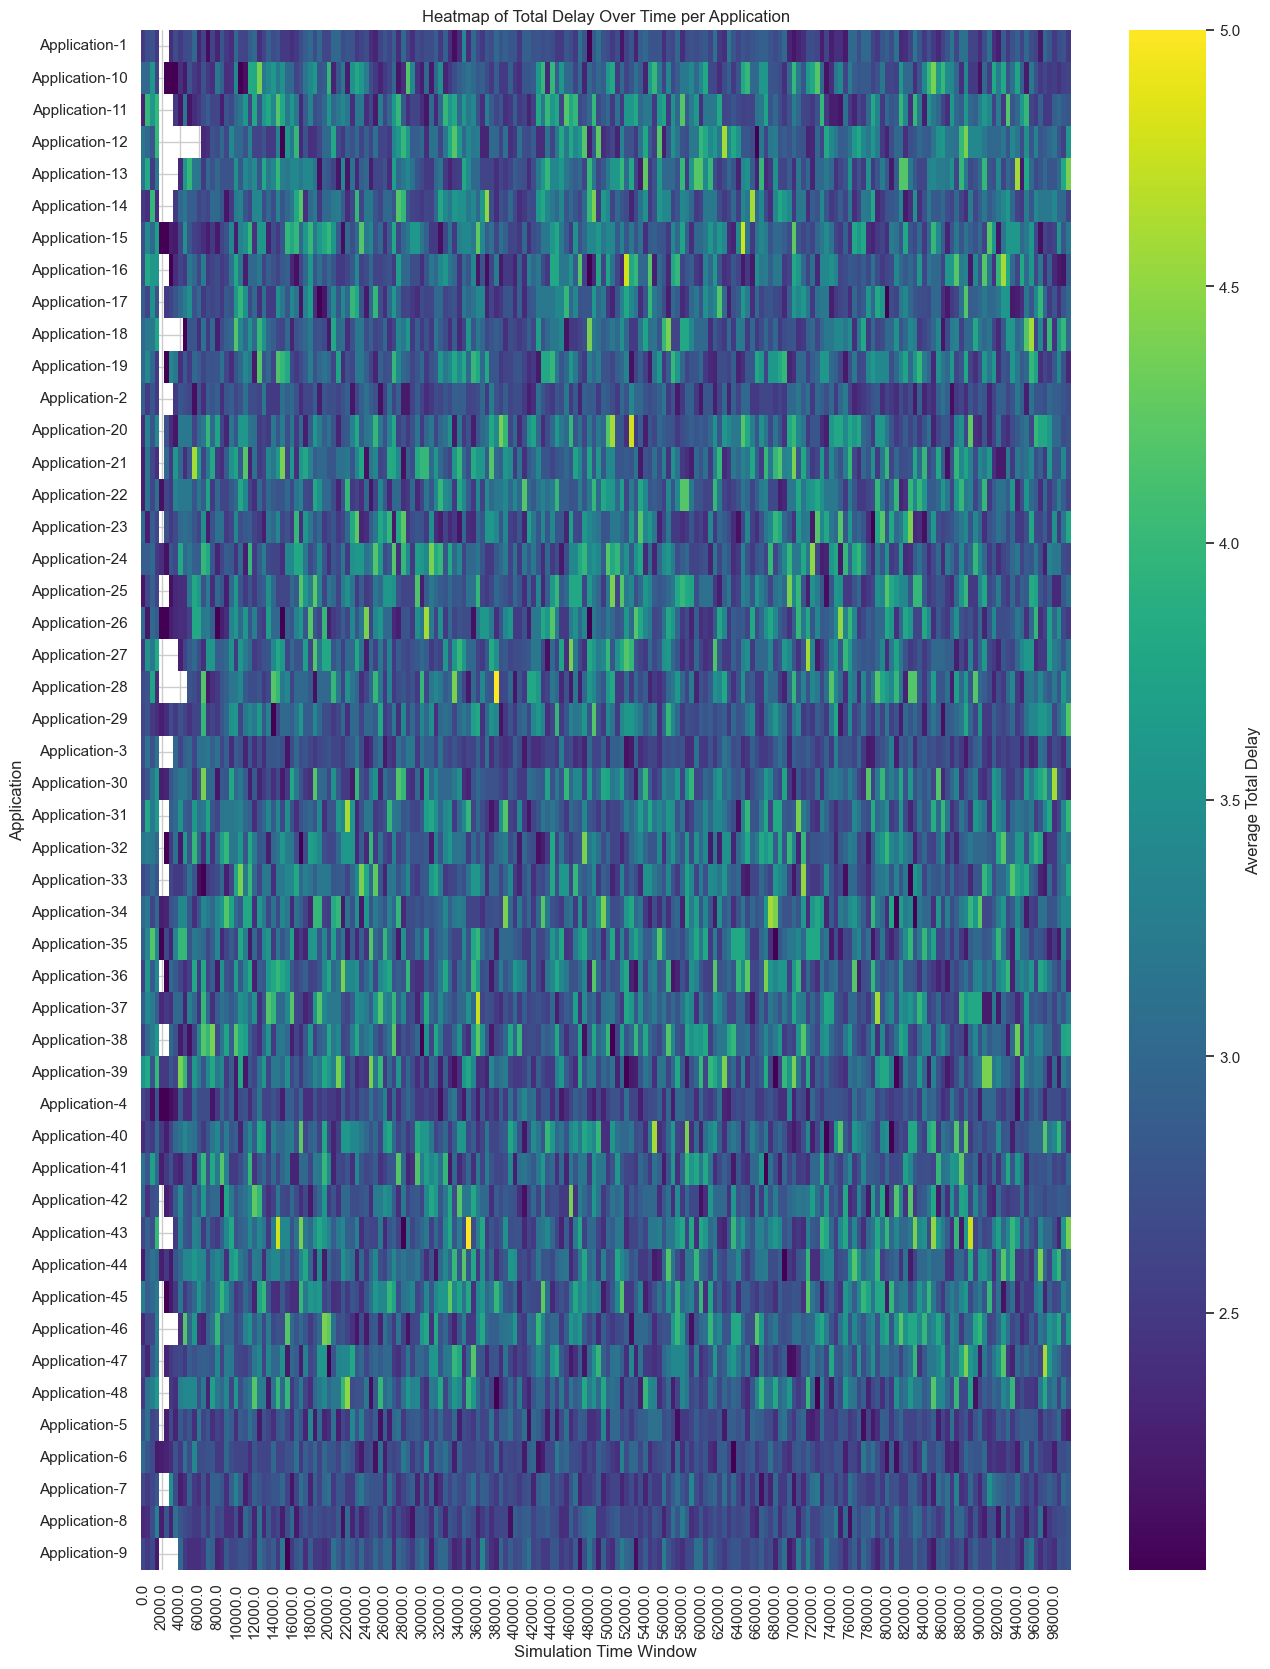

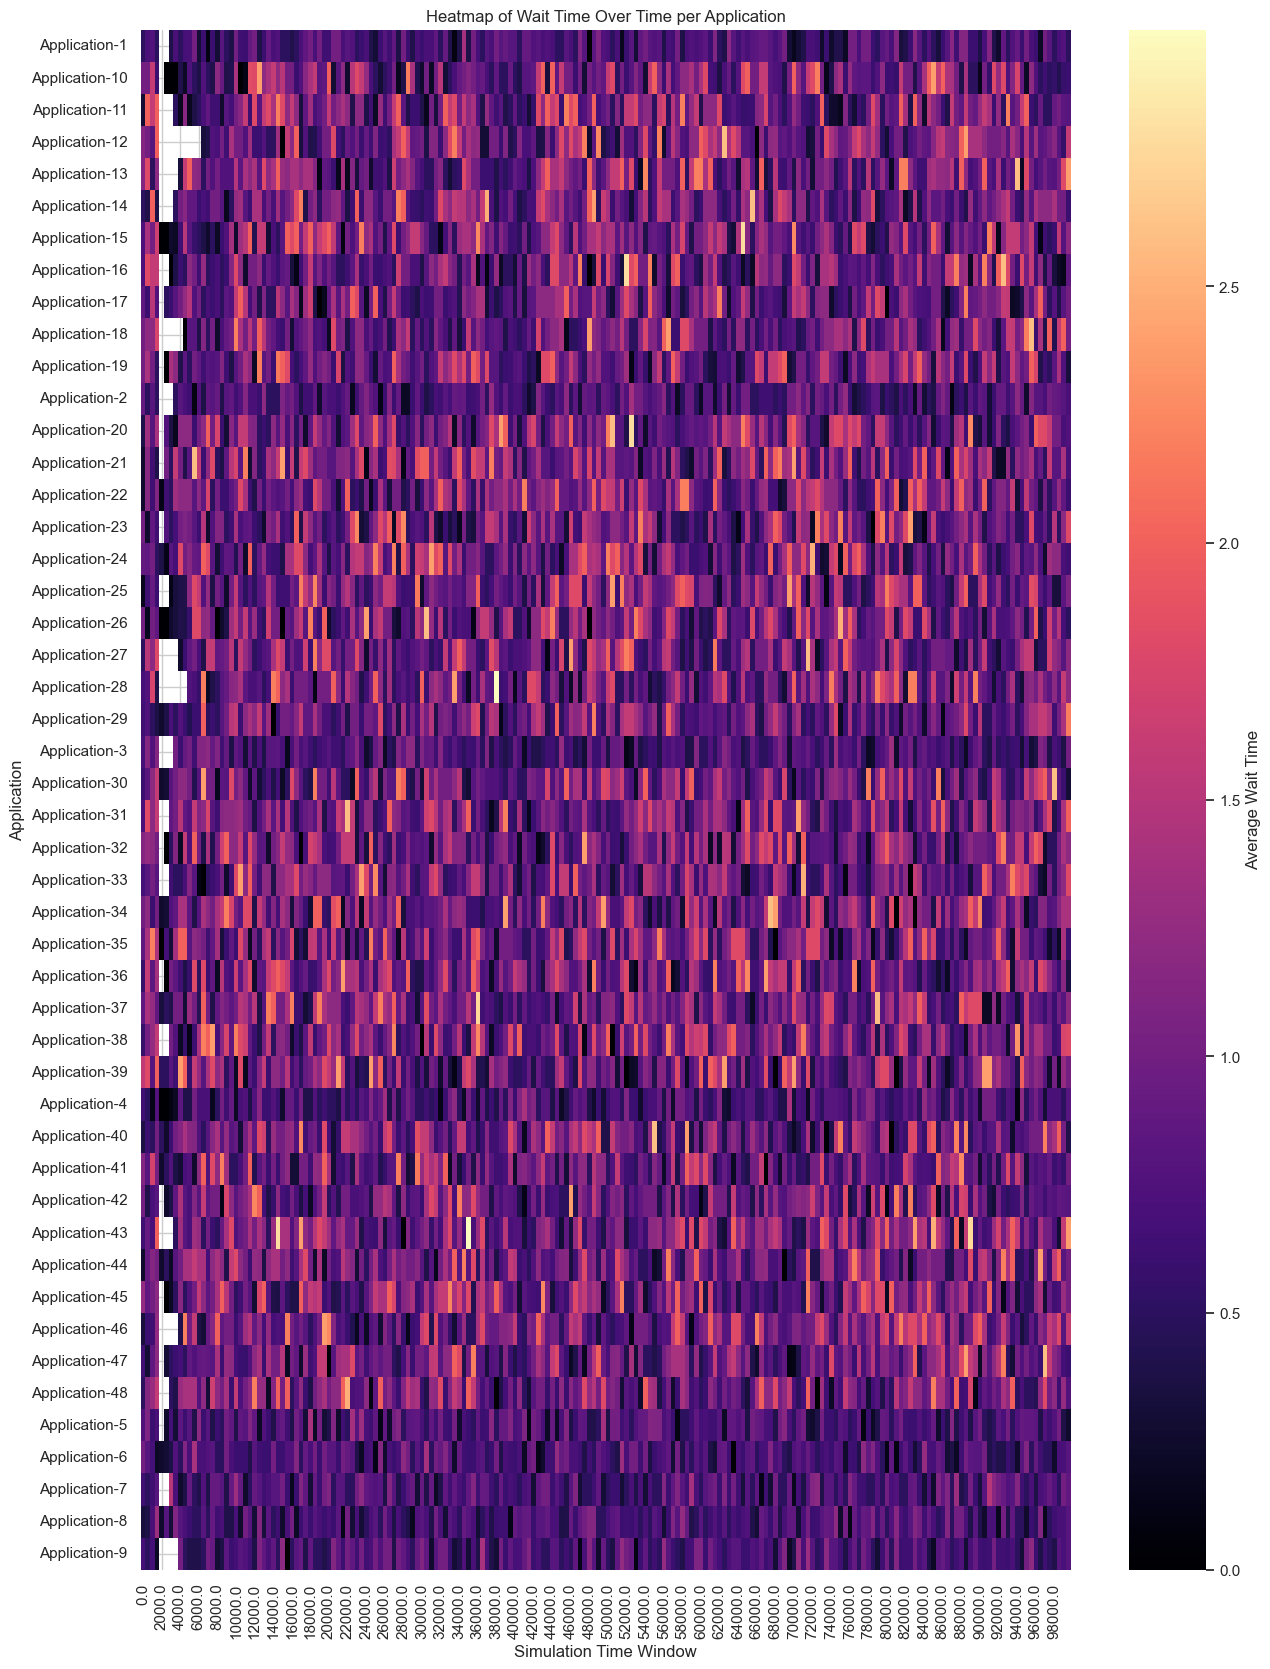

In [53]:
# Define time window size for averaging (e.g., 500 time units)
# You can adjust this value based on your simulation duration
window_size = 500 

# Create a new column for time windows
df_link['time_window'] = (df_link['ctime'] // window_size) * window_size

# Calculate mean latency per time window
latency_trend = df_link.groupby('time_window')[['latency', 'total_delay', 'wait']].mean().reset_index()

# Plot Global Average Latency vs Wait vs Total
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_window', y='latency', data=latency_trend, marker='o', label='Transmission Latency')
sns.lineplot(x='time_window', y='wait', data=latency_trend, marker='o', label='Wait Time')
sns.lineplot(x='time_window', y='total_delay', data=latency_trend, marker='o', label='Total Delay')
plt.title(f'Global Average Delays Over Time (Window Size: {window_size})')
plt.xlabel('Simulation Time')
plt.ylabel('Average Time')
plt.legend()
plt.grid(True)
plt.show()

# --- Improved Per-Application Analysis ---

# 1. Line Plot for Top 10 Applications (by message count)
# Plotting all 80+ applications results in an unreadable plot and legend.
top_apps = df_link['app'].value_counts().nlargest(10).index
df_top_apps = df_link[df_link['app'].isin(top_apps)]

plt.figure(figsize=(12, 6))
latency_trend_app = df_top_apps.groupby(['time_window', 'app'])['total_delay'].mean().reset_index()
sns.lineplot(x='time_window', y='total_delay', hue='app', data=latency_trend_app, marker='o')
plt.title(f'Average Total Delay Over Time (Top 10 Active Applications)')
plt.xlabel('Simulation Time')
plt.ylabel('Average Total Delay')
plt.legend(title='Application', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# 2. Heatmap for ALL Applications (Total Delay)
# A heatmap is better for visualizing latency trends across many applications simultaneously.
latency_pivot = df_link.pivot_table(index='app', columns='time_window', values='total_delay', aggfunc='mean')

plt.figure(figsize=(15, 20)) # Taller figure for many apps
sns.heatmap(latency_pivot, cmap='viridis', annot=False, cbar_kws={'label': 'Average Total Delay'})
plt.title('Heatmap of Total Delay Over Time per Application')
plt.xlabel('Simulation Time Window')
plt.ylabel('Application')
plt.show()

# 3. Heatmap for ALL Applications (Wait Time)
if 'wait' in df_link.columns:
    wait_pivot = df_link.pivot_table(index='app', columns='time_window', values='wait', aggfunc='mean')

    plt.figure(figsize=(15, 20)) # Taller figure for many apps
    sns.heatmap(wait_pivot, cmap='magma', annot=False, cbar_kws={'label': 'Average Wait Time'})
    plt.title('Heatmap of Wait Time Over Time per Application')
    plt.xlabel('Simulation Time Window')
    plt.ylabel('Application')
    plt.show()

## 3. Traffic Analysis
We will analyze the volume of traffic generated by each application and visualize the communication patterns between nodes using a heatmap.

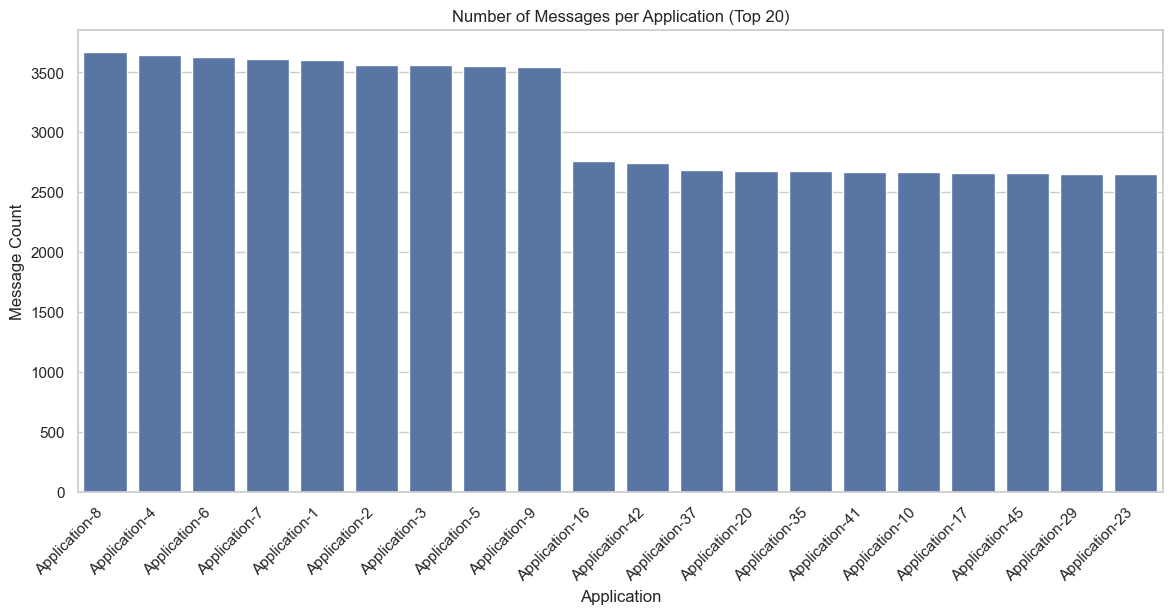

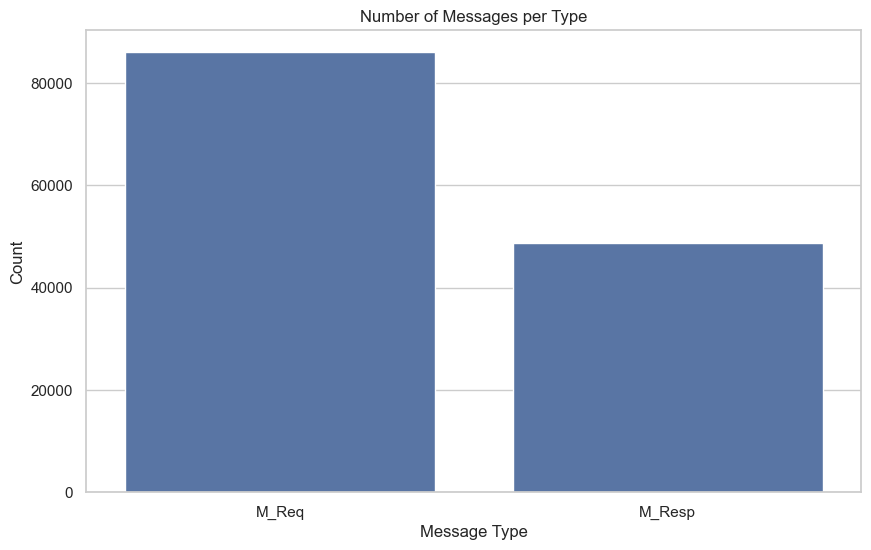

Heatmap is too large ((72, 72)), filtering to top 30 active nodes.


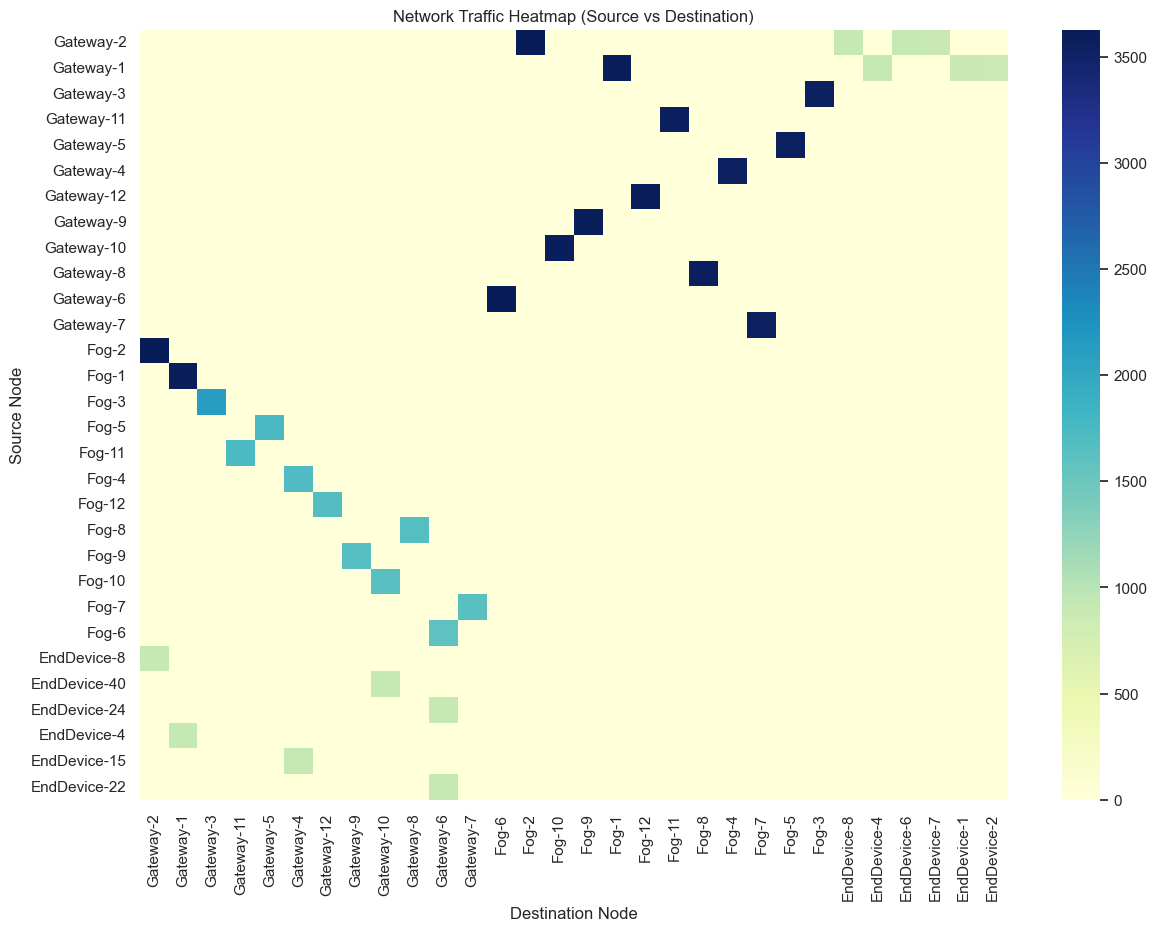

In [54]:
# Message Count per Application (Top 20)
plt.figure(figsize=(14, 6))
# Get top 20 apps
top_20_apps_count = df_link['app'].value_counts().nlargest(20)
sns.barplot(x=top_20_apps_count.index, y=top_20_apps_count.values)
plt.title('Number of Messages per Application (Top 20)')
plt.xlabel('Application')
plt.ylabel('Message Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Message Count per Message Type
if 'message' in df_link.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='message', data=df_link)
    plt.title('Number of Messages per Type')
    plt.xlabel('Message Type')
    plt.ylabel('Count')
    plt.show()

# Communication Heatmap (Source vs Destination)
# Create a pivot table counting occurrences
# We might need to filter this too if there are too many nodes, but let's try full first or filter by top interactions
heatmap_data = pd.crosstab(df_link['srcLabel'], df_link['dstLabel'])

# Check size of heatmap
if heatmap_data.shape[0] > 50 or heatmap_data.shape[1] > 50:
    print(f"Heatmap is too large ({heatmap_data.shape}), filtering to top 30 active nodes.")
    # Filter to top 30 active nodes (by sum of outgoing/incoming)
    top_src = heatmap_data.sum(axis=1).nlargest(30).index
    top_dst = heatmap_data.sum(axis=0).nlargest(30).index
    heatmap_data = heatmap_data.loc[top_src, top_dst]

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=False, fmt='d', cmap='YlGnBu') # annot=False for cleaner view if dense
plt.title('Network Traffic Heatmap (Source vs Destination)')
plt.xlabel('Destination Node')
plt.ylabel('Source Node')
plt.show()

## 4. Buffer Usage Analysis
Understanding buffer usage is crucial for identifying potential congestion points. We will look at the distribution of buffer sizes and how buffer usage changes over time.

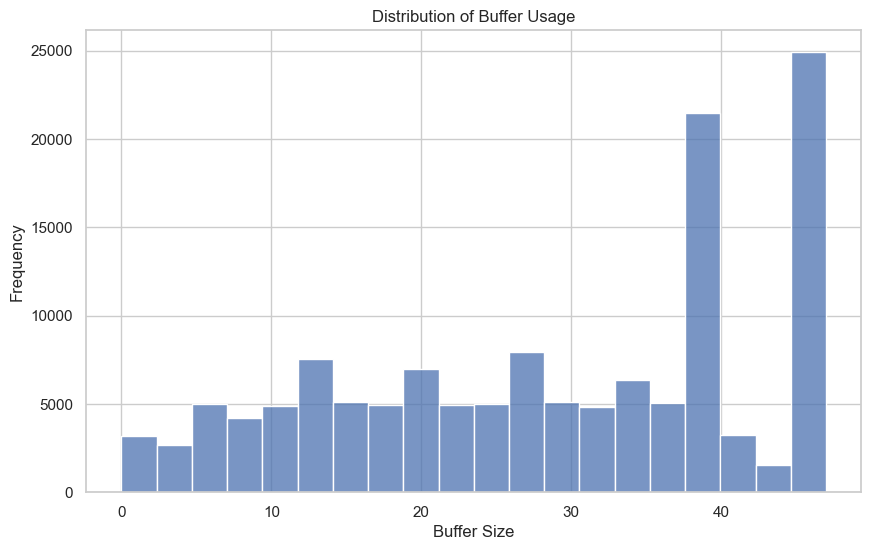

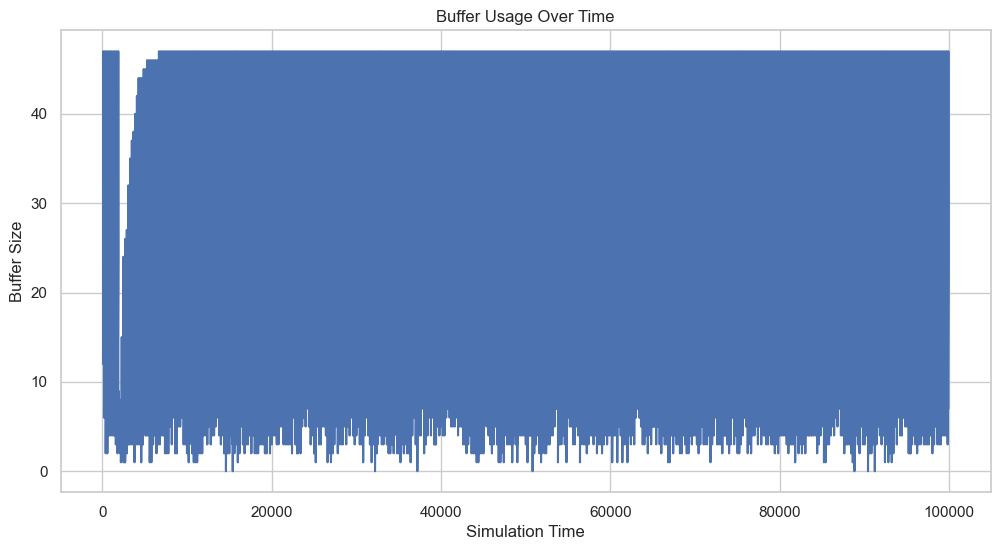

In [55]:
# Buffer Size Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_link['buffer'], bins=20, kde=False)
plt.title('Distribution of Buffer Usage')
plt.xlabel('Buffer Size')
plt.ylabel('Frequency')
plt.show()

# Buffer Usage Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='ctime', y='buffer', data=df_link)
plt.title('Buffer Usage Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Buffer Size')
plt.show()

## 5. Throughput Analysis
We will visualize the cumulative data transferred over the network to understand the throughput of the system.

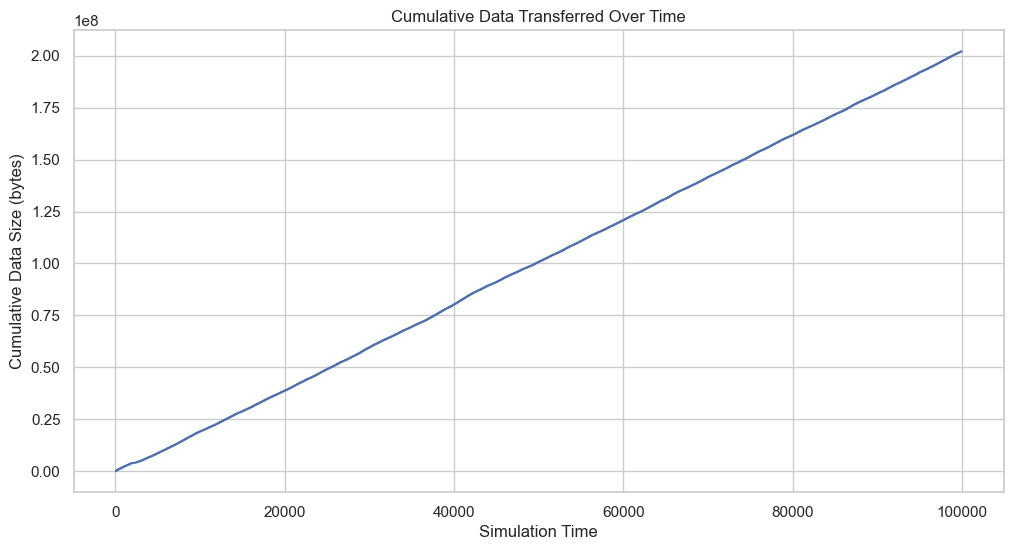

In [56]:
# Sort by time
df_link_sorted = df_link.sort_values('ctime')

# Calculate cumulative size
df_link_sorted['cumulative_size'] = df_link_sorted['size'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(df_link_sorted['ctime'], df_link_sorted['cumulative_size'])
plt.title('Cumulative Data Transferred Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Cumulative Data Size (bytes)')
plt.show()

## 6. Conclusion
This notebook provides a detailed analysis of the network link traces.
- **Latency**: Check if any application experiences abnormal delays.
- **Traffic**: Identify the most communicative nodes using the heatmap.
- **Buffer**: Ensure buffers are not consistently full, which would indicate congestion.
- **Throughput**: Observe the rate of data transfer over the simulation period.